# GrayScaling Images

## Objectives:

1. Converting color image to gray scale
2. Observe the change in Depth of the Image

> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
import cv2
from matplotlib import pyplot as plt

In [2]:
# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

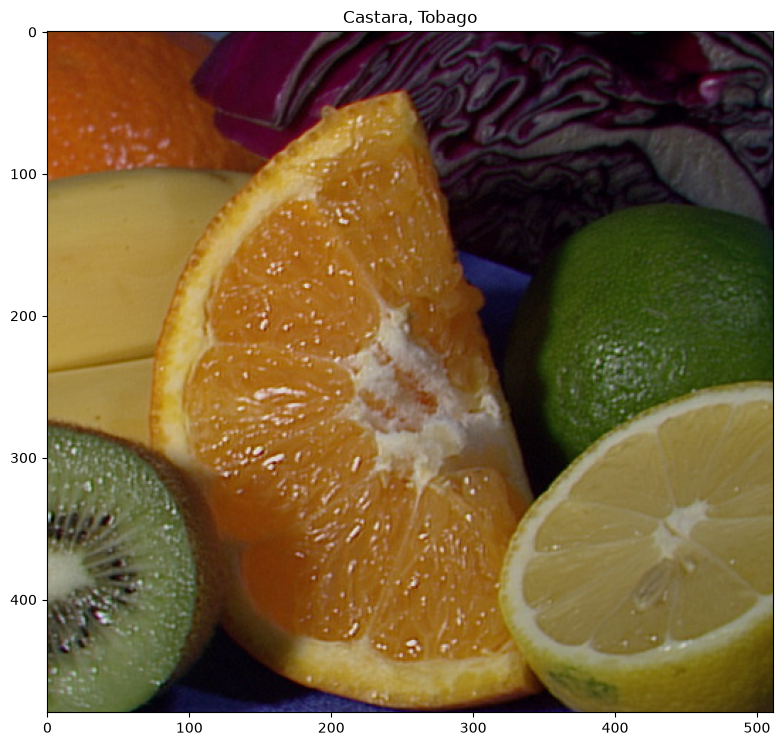

In [3]:
# Load our input image
image = cv2.imread('./assets/images/castara.jpeg')

imshow("Castara, Tobago", image)

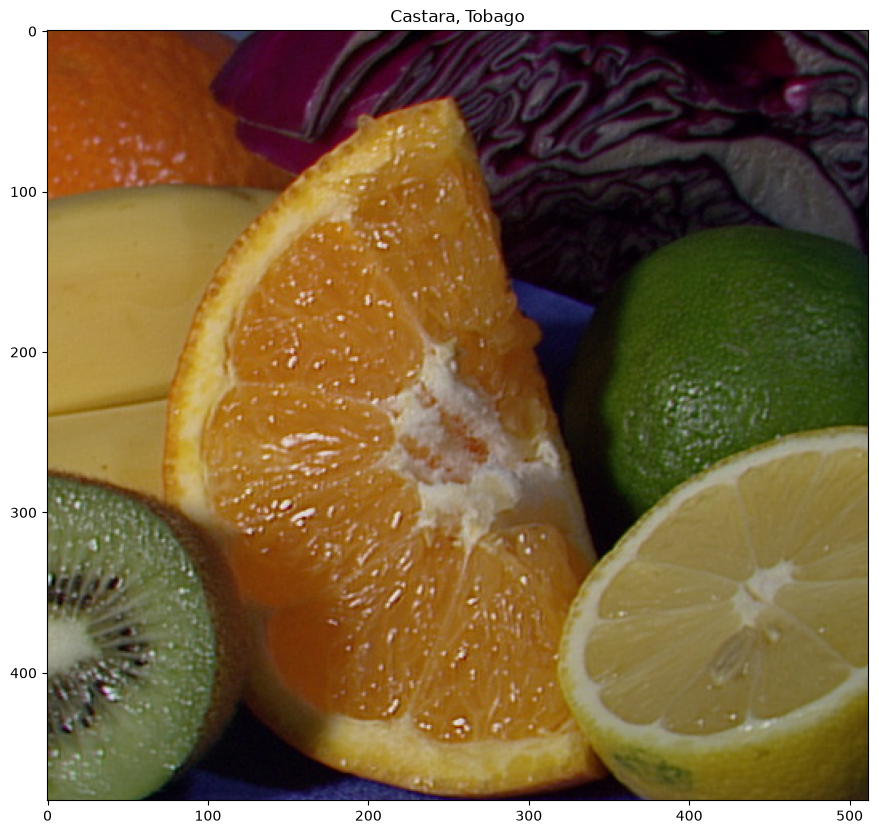

In [4]:
image.shape[:2] # (1200, 1920) (height, width)
def imshow(title = "", image = None, size = 10):
 
    # The line below is changed from w, h to h, w
    h, w = image.shape[0], image.shape[1]
    aspect_ratio = w/h
 
    plt.figure(figsize=(size * aspect_ratio, size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

imshow("Castara, Tobago", image)

### Why isn't grayscale just `(R + G + B) / 3`?

`COLOR_BGR2GRAY` doesn't average the three channels — it computes a **weighted** sum:

$$\text{Gray} = 0.299\,R + 0.587\,G + 0.114\,B$$

The weights track how sensitive the human eye actually is to each color, not how bright each channel is numerically. We're most sensitive to green light, least to blue — a green pixel *reads* as brighter to us than a blue pixel of the same value, so grayscale conversion gives green almost 5x the weight of blue. Try it: swap the formula for a plain average (`(B.astype(float)+G+R)/3`) on the same image and diff the two grayscale results — the difference concentrates exactly where the image is strongly blue or green, not where it's red.

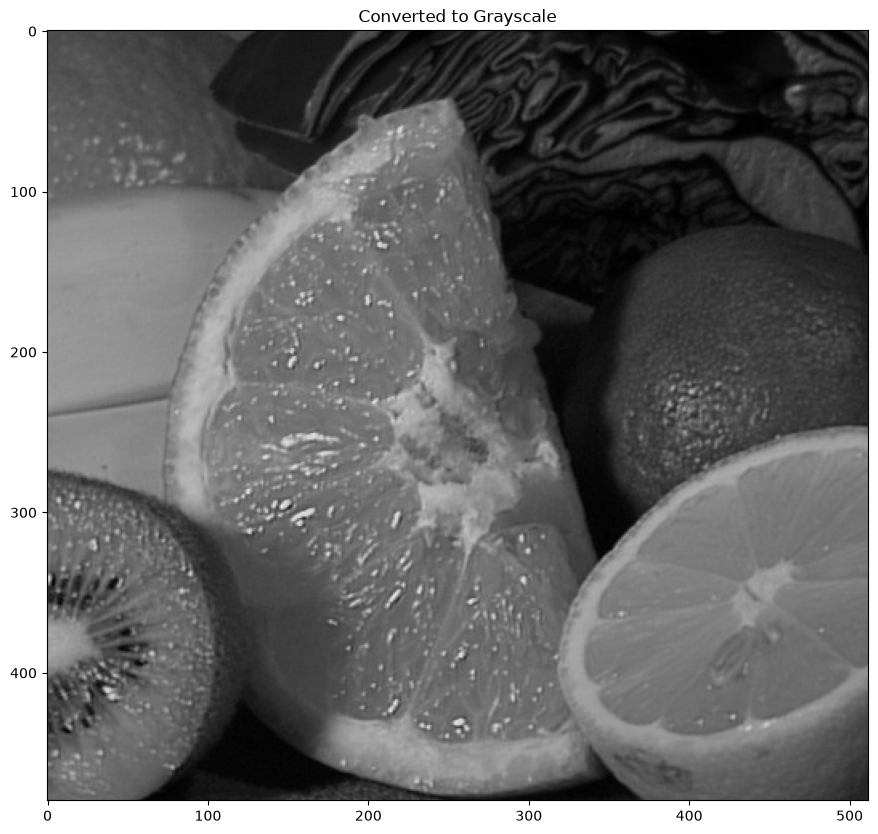

In [5]:
# We use cvtColor, to convert to grayscale
# It takes 2 arguments, the first being the input image
# The second being the color space conversion code 
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

imshow("Converted to Grayscale", gray_image)

In [6]:
image.shape

(480, 512, 3)

In [7]:
gray_image.shape

(480, 512)

### Worth trying next

- Grayscale is a weighted sum, not a plain average — `cv2.cvtColor` uses `0.299R + 0.587G + 0.114B`. Recompute it by hand with `B,G,R = cv2.split(image)` and compare to `cv2.cvtColor`'s result with `np.allclose`.
- Try loading directly as grayscale with `cv2.imread(path, cv2.IMREAD_GRAYSCALE)` instead of converting after the fact — same result, less work.